In [66]:
### ANN for bank churn prediction

%matplotlib inline
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix


In [67]:
df = pd.read_csv("Churn_Modelling.csv")
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [68]:
df.drop("Surname", axis=1, inplace=True)
df.drop("CustomerId", axis=1, inplace=True)

In [69]:
df.head()

,RowNumber,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [70]:
### Encoding gender and geography using one hot encoding

def get_unique(df):
    for col in df:
        if df[col].dtypes=='object':
            print("{} : {}".format(col, df[col].unique()))

get_unique(df)

df2 = pd.get_dummies(df)


Geography : ['France' 'Spain' 'Germany']
Gender : ['Female' 'Male']


In [71]:
df2.head()

,RowNumber,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
0,1,619,42,2,0.00,1,1,1,101348.88,1,True,False,False,True,False
1,2,608,41,1,83807.86,1,0,1,112542.58,0,False,False,True,True,False
2,3,502,42,8,159660.80,3,1,0,113931.57,1,True,False,False,True,False
3,4,699,39,1,0.00,2,0,0,93826.63,0,True,False,False,True,False
4,5,850,43,2,125510.82,1,1,1,79084.10,0,False,False,True,True,False


In [72]:
### train test split

X = df2.drop("Exited", axis=1)
y = df2["Exited"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=10)


In [73]:
X_train.shape

(7000, 14)

In [74]:
y_train.shape

(7000,)

In [75]:
### building the model

model = keras.Sequential([
    keras.layers.Dense(14, input_shape=(14,), activation="relu"),
    keras.layers.Dense(20, activation="relu"),
    keras.layers.Dense(1,  activation="sigmoid"),
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.fit(X_train, y_train, epochs=20)

Epoch 1/20


c:\Users\premt\OneDrive\Desktop\Programming\Portfolio\ml-algorithms\.venv\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 919us/step - accuracy: 0.6939 - loss: 232.2458
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 765us/step - accuracy: 0.6947 - loss: 118.5320
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 815us/step - accuracy: 0.6811 - loss: 84.9219 
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 848us/step - accuracy: 0.6876 - loss: 77.8441
Epoch 5/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 815us/step - accuracy: 0.6961 - loss: 58.1720
Epoch 6/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 757us/step - accuracy: 0.6907 - loss: 61.0444
Epoch 7/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 860us/step - accuracy: 0.6861 - loss: 59.1790
Epoch 8/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 842us/step - accuracy: 0.6874 - loss: 57.7631
Epoch 9/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 883us/step - accuracy: 0.6864 - loss: 64.2717
Epoch 10/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 932us/step - accuracy: 0.6894 - loss: 58.4661
Epoch 11/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 891us/step - accuracy: 0.6819 - loss: 60.5005
Epoch 12/20
219/219 ━━━━━━━

In [76]:
model.evaluate(X_test, y_test)

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 812us/step - accuracy: 0.7933 - loss: 93.5305


[93.53047943115234, 0.7933333516120911]

In [77]:
y_preds = model.predict(X_test)
y_preds[:5]

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 646us/step


array([[0.],
       [0.],
       [0.],
       [0.],
       [0.]], dtype=float32)

In [78]:
predictions = []
for pred in y_preds:
    if pred > 0.5:
        predictions.append(1)
    else:
        predictions.append(0)

predictions[:5]


[0, 0, 0, 0, 0]

In [79]:
y_test[:5]

937     0
9355    0
2293    1
192     0
8675    0
Name: Exited, dtype: int64

In [80]:
report = classification_report(y_test, predictions)
print(report)

              precision    recall  f1-score   support

           0       0.79      1.00      0.88      2380
           1       0.00      0.00      0.00       620

    accuracy                           0.79      3000
   macro avg       0.40      0.50      0.44      3000
weighted avg       0.63      0.79      0.70      3000



c:\Users\premt\OneDrive\Desktop\Programming\Portfolio\ml-algorithms\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\premt\OneDrive\Desktop\Programming\Portfolio\ml-algorithms\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\premt\OneDrive\Desktop\Programming\Portfolio\ml-algorithms\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_divi

TypeError: 'str' object is not callable

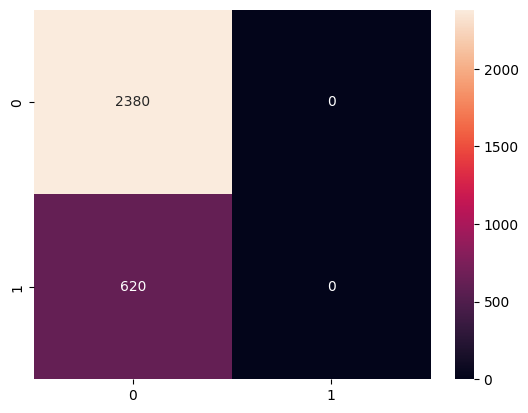

In [81]:
conf_matix = confusion_matrix(y_test, predictions)

sns.heatmap(conf_matix, annot=True, fmt='d')
plt.xlabel(xlabel="predictions")
plt.ylabel(ylabel="truth")